In [11]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split

# --- 1. Extraction ---
if os.path.exists("dataset.zip"):
    !unzip -q dataset.zip -d ./working_dir
else:
    print("Please upload dataset.zip to the sidebar first!")

# --- 2. Loader Function ---
def load_my_images(path, dim=64):
    x_list, y_list = [], []
    folders = ["cats_set", "dogs_set"]

    for label_val, folder_name in enumerate(folders):
        # Look for the folders specifically
        target = os.path.join(path, "**", folder_name)
        found = glob.glob(target, recursive=True)

        if found:
            img_dir = found[0]
            for f in os.listdir(img_dir):
                if f.lower().endswith(('.jpg', '.png', '.jpeg')):
                    try:
                        # Process image
                        full_p = os.path.join(img_dir, f)
                        temp_img = Image.open(full_p).convert("RGB").resize((dim, dim))
                        # Flatten and normalize
                        vec = np.array(temp_img, dtype=np.float32).flatten() / 255.0
                        x_list.append(vec)
                        y_list.append(label_val)
                    except:
                        continue
    return np.array(x_list), np.array(y_list)

# Load and Split
X_all, y_all = load_my_images("./working_dir")
if len(X_all) > 0:
    X_train, X_temp, y_train, y_temp = train_test_split(X_all, y_all, test_size=0.3, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
    print(f"Loaded {len(X_all)} images. Training on {len(X_train)}.")

Loaded 1000 images. Training on 700.


In [19]:
# Mathematics and the activation Functions
def leaky_relu(v, alpha=0.01):
    return np.where(v > 0, v, v * alpha)

def leaky_relu_prime(v, alpha=0.01):
    dx = np.ones_like(v)
    dx[v <= 0] = alpha
    return dx

def sigmoid(v):
    return 1 / (1 + np.exp(-np.clip(v, -250, 250)))

def sigmoid_prime(v):
    s = sigmoid(v)
    return s * (1 - s)

def bce_loss(actual, pred):
    # Standard Binary Cross Entropy
    small_val = 1e-10
    pred = np.clip(pred, small_val, 1 - small_val)
    return -np.mean(actual * np.log(pred) + (1 - actual) * np.log(1 - pred))

In [23]:
class BrainNet:
    def __init__(self, layers, lr=0.0001): # Default to a much smaller LR
        self.layers = layers
        self.lr = lr
        self.weights = []
        self.biases = []
        self.mw, self.vw = [], []
        self.mb, self.vb = [], []
        self.time = 0

        for i in range(len(layers) - 1):
            # XAVIER INITIALIZATION: This is the key to fixing the 11.0 loss
            scale = np.sqrt(1.0 / layers[i])
            w = np.random.randn(layers[i], layers[i+1]) * scale
            b = np.zeros((1, layers[i+1]))

            self.weights.append(w)
            self.biases.append(b)
            self.mw.append(np.zeros_like(w))
            self.vw.append(np.zeros_like(w))
            self.mb.append(np.zeros_like(b))
            self.vb.append(np.zeros_like(b))

    def step_forward(self, x):
        self.a_vals = [x]
        self.z_vals = []
        curr = x
        for i in range(len(self.weights)):
            z = curr @ self.weights[i] + self.biases[i]
            self.z_vals.append(z)
            curr = sigmoid(z) if i == len(self.weights)-1 else leaky_relu(z)
            self.a_vals.append(curr)
        return curr

    def step_backward(self, y_true):
        m = y_true.shape[0]
        y_true = y_true.reshape(-1, 1)
        self.time += 1

        error = (self.a_vals[-1] - y_true) / m

        for i in reversed(range(len(self.weights))):
            z = self.z_vals[i]
            delta = error * (sigmoid_prime(z) if i == len(self.weights)-1 else leaky_relu_prime(z))

            dw = self.a_vals[i].T @ delta
            db = np.sum(delta, axis=0, keepdims=True)
            error = delta @ self.weights[i].T

            # Adam update logic
            b1, b2, eps = 0.9, 0.999, 1e-8
            self.mw[i] = b1 * self.mw[i] + (1 - b1) * dw
            self.vw[i] = b2 * self.vw[i] + (1 - b2) * (dw**2)
            self.mb[i] = b1 * self.mb[i] + (1 - b1) * db
            self.vb[i] = b2 * self.vb[i] + (1 - b2) * (db**2)

            mwh, vwh = self.mw[i]/(1-b1**self.time), self.vw[i]/(1-b2**self.time)
            mbh, vbh = self.mb[i]/(1-b1**self.time), self.vb[i]/(1-b2**self.time)

            self.weights[i] -= self.lr * mwh / (np.sqrt(vwh) + eps)
            self.biases[i] -= self.lr * mbh / (np.sqrt(vbh) + eps)

In [21]:
def get_manual_report(actual, probs):
    actual = actual.flatten()
    # 0.5 Threshold for binary prediction
    preds = (probs >= 0.5).astype(int)

    # We create a dictionary to store stats for each class
    report = {}

    # Loop through class 0 (Cat) and class 1 (Dog)
    for label in [0, 1]:
        name = "Cat" if label == 0 else "Dog"

        # Logic for each class:
        # TP: predicted this class and it was this class
        # FP: predicted this class but it was the other
        # FN: predicted the other class but it was this one
        tp = np.sum((preds == label) & (actual == label))
        fp = np.sum((preds == label) & (actual != label))
        fn = np.sum((preds != label) & (actual == label))

        # Standard formulas with a small epsilon to prevent 0 division
        precision = tp / (tp + fp + 1e-9)
        recall = tp / (tp + fn + 1e-9)
        f1 = 2 * (precision * recall) / (precision + recall + 1e-9)

        report[name] = {"P": precision, "R": recall, "F1": f1}

    # We also calculate the FPR and TPR for the ROC curve here
    # by sweeping through 100 different thresholds
    thresholds = np.linspace(1, 0, 100)
    fpr_list, tpr_list = [], []

    num_pos = np.sum(actual == 1)
    num_neg = np.sum(actual == 0)

    for t in thresholds:
        p_at_t = (probs >= t).astype(int)
        tp_t = np.sum((p_at_t == 1) & (actual == 1))
        fp_t = np.sum((p_at_t == 1) & (actual == 0))

        # True Positive Rate and False Positive Rate
        tpr_list.append(tp_t / (num_pos + 1e-9))
        fpr_list.append(fp_t / (num_neg + 1e-9))

    return report, fpr_list, tpr_list



def get_performance(actual, probs):
    # Flatten everything to ensure 1D arrays
    actual = actual.flatten()
    preds = (probs >= 0.5).astype(int)

    # Calculate base counts
    tp = np.sum((preds == 1) & (actual == 1))
    tn = np.sum((preds == 0) & (actual == 0))
    fp = np.sum((preds == 1) & (actual == 0))
    fn = np.sum((preds == 0) & (actual == 1))

    # Standard Metric Math
    accuracy = (tp + tn) / len(actual)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    # Calculate AUC using the trapezoidal ranking method
    # This is a very common "from scratch" logic for AUC
    indices = np.argsort(probs)[::-1]
    sorted_labels = actual[indices]

    total_pos = np.sum(actual)
    total_neg = len(actual) - total_pos

    tp_so_far, accumulated_area = 0, 0
    for label in sorted_labels:
        if label == 1:
            tp_so_far += 1
        else:
            accumulated_area += tp_so_far

    auc = accumulated_area / (total_pos * total_neg) if (total_pos * total_neg) > 0 else 0

    # Returning the confusion matrix as a standard list for seaborn
    matrix = [[int(tn), int(fp)], [int(fn), int(tp)]]

    return accuracy, precision, recall, f1_score, auc, matrix

def get_roc_coordinates(actual, probs):
    actual = actual.flatten()
    # Create 100 different thresholds from 0 to 1
    thresholds = np.linspace(1, 0, 100)

    tpr_list = []
    fpr_list = []

    pos_count = np.sum(actual == 1)
    neg_count = np.sum(actual == 0)

    for t in thresholds:
        # For every threshold, calculate a new TP and FP count
        current_preds = (probs >= t).astype(int)
        tp = np.sum((current_preds == 1) & (actual == 1))
        fp = np.sum((current_preds == 1) & (actual == 0))

        tpr_list.append(tp / pos_count)
        fpr_list.append(fp / neg_count)

    return fpr_list, tpr_list

Starting Training...
------------------------------
Epoch 1: Loss = 0.6763, Acc = 0.6133
Epoch 5: Loss = 0.6816, Acc = 0.5600
Epoch 10: Loss = 0.6789, Acc = 0.5933
Epoch 15: Loss = 0.6753, Acc = 0.6067
Epoch 20: Loss = 0.6995, Acc = 0.5933
Epoch 25: Loss = 0.6957, Acc = 0.5867
Epoch 30: Loss = 0.7076, Acc = 0.5733
Epoch 35: Loss = 0.7080, Acc = 0.6133
Epoch 40: Loss = 0.7237, Acc = 0.5867
Epoch 45: Loss = 0.7258, Acc = 0.6000
Epoch 50: Loss = 0.7480, Acc = 0.5600

       FINAL LAB PERFORMANCE REPORT
Test Accuracy : 0.5667
Test Precision: 0.5522
Test Recall   : 0.5139
Test F1 Score : 0.5324
Test ROC-AUC  : 0.5962
----------------------------------------


<Figure size 1800x500 with 0 Axes>

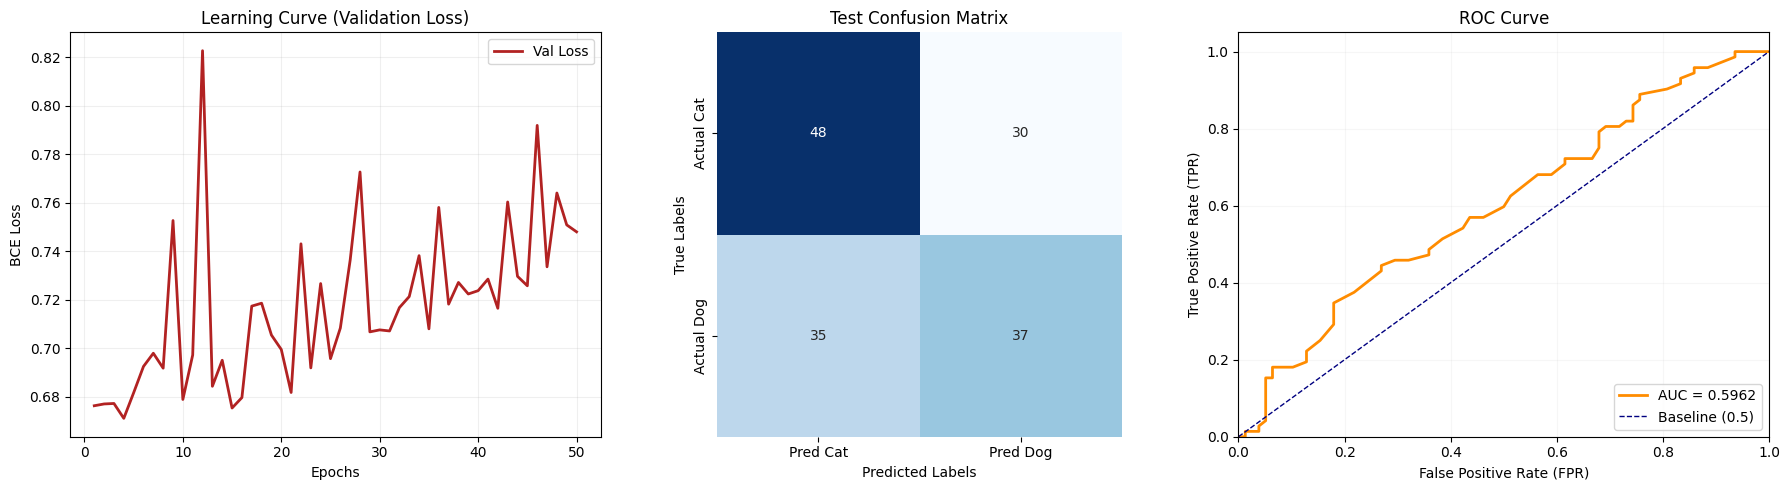

In [25]:

net = BrainNet([X_train.shape[1], 64, 32, 1], lr=0.0001)
history = {"loss": [], "acc": []}

print("Starting Training...")
print("-" * 30)

# --- 2. The Training Loop ---
for epoch in range(50):
    p = np.random.permutation(len(X_train))
    x_s, y_s = X_train[p], y_train[p]

    # 3. Smaller Batch Size (16) adds noise that helps escape the Dog Bias plateau
    for i in range(0, len(X_train), 16):
        xb, yb = x_s[i:i+16], y_s[i:i+16]
        net.step_forward(xb)
        net.step_backward(yb)

    # Progress check
    v_probs = net.step_forward(X_val).flatten()
    v_acc = np.mean((v_probs >= 0.5) == y_val)
    v_loss = bce_loss(y_val, v_probs)

    history["loss"].append(v_loss)
    history["acc"].append(v_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}: Loss = {v_loss:.4f}, Acc = {v_acc:.4f}")


# --- 3. Final Evaluation (Test Set) ---
test_output = net.step_forward(X_test).flatten()

# Using the manual performance function we wrote earlier
accuracy, precision, recall, f1, auc_score, conf_matrix = get_performance(y_test, test_output)
# Using our manual ROC coordinate function
fpr_points, tpr_points = get_roc_coordinates(y_test, test_output)
# Get per-class report
class_report, _, _ = get_manual_report(y_test, test_output)

# --- 4. Final Lab Report Output ---
print("\n" + "="*40)
print("       FINAL LAB PERFORMANCE REPORT")
print("="*40)
print(f"Test Accuracy : {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall   : {recall:.4f}")
print(f"Test F1 Score : {f1:.4f}")
print(f"Test ROC-AUC  : {auc_score:.4f}")
print("-" * 40)

# --- 5. Visualizations ---
plt.figure(figsize=(18, 5))

# --- 5. Visualizations (Refined) ---
plt.figure(figsize=(18, 5))

# Graph A: Learning Curve (Loss over time)
plt.subplot(1, 3, 1)
# Use dynamic length to avoid the dimension mismatch error
history_range = range(1, len(history["loss"]) + 1)
plt.plot(history_range, history["loss"], color='firebrick', linewidth=2, label='Val Loss')
plt.title("Learning Curve (Validation Loss)")
plt.xlabel("Epochs")
plt.ylabel("BCE Loss")
plt.legend()
plt.grid(True, alpha=0.2)

# Graph B: Confusion Matrix
plt.subplot(1, 3, 2)
# Using 'conf_matrix' - ensure this matches your evaluation output name
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', square=True, cbar=False,
            xticklabels=['Pred Cat', 'Pred Dog'],
            yticklabels=['Actual Cat', 'Actual Dog'])
plt.title("Test Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")

# Graph C: ROC Curve (Manual)
plt.subplot(1, 3, 3)
# Ensure auc_score is the variable returned by your get_performance function
plt.plot(fpr_points, tpr_points, color='darkorange', lw=2, label=f'AUC = {auc_score:.4f}')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Baseline (0.5)')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.legend(loc="lower right")
plt.grid(True, alpha=0.1)

plt.tight_layout()
plt.show()

Final Training Session Starting...
Epoch 1/20 | Loss: 0.6846 | Acc: 0.5600
Epoch 2/20 | Loss: 0.6792 | Acc: 0.5933
Epoch 3/20 | Loss: 0.6895 | Acc: 0.5133
Epoch 4/20 | Loss: 0.6736 | Acc: 0.6200
Epoch 5/20 | Loss: 0.6721 | Acc: 0.5733
Epoch 6/20 | Loss: 0.7244 | Acc: 0.4800
Epoch 7/20 | Loss: 0.6980 | Acc: 0.5400
Epoch 8/20 | Loss: 0.7421 | Acc: 0.4933
Epoch 9/20 | Loss: 0.7232 | Acc: 0.4867
Epoch 10/20 | Loss: 0.6796 | Acc: 0.5800
Epoch 11/20 | Loss: 0.6711 | Acc: 0.5800
Epoch 12/20 | Loss: 0.6853 | Acc: 0.5733
Epoch 13/20 | Loss: 0.7283 | Acc: 0.5400
Epoch 14/20 | Loss: 0.6777 | Acc: 0.6000
Epoch 15/20 | Loss: 0.6770 | Acc: 0.5667
Epoch 16/20 | Loss: 0.6792 | Acc: 0.5533
Epoch 17/20 | Loss: 0.6741 | Acc: 0.5667
Epoch 18/20 | Loss: 0.6888 | Acc: 0.6200
Epoch 19/20 | Loss: 0.6861 | Acc: 0.5933
Epoch 20/20 | Loss: 0.6834 | Acc: 0.6333


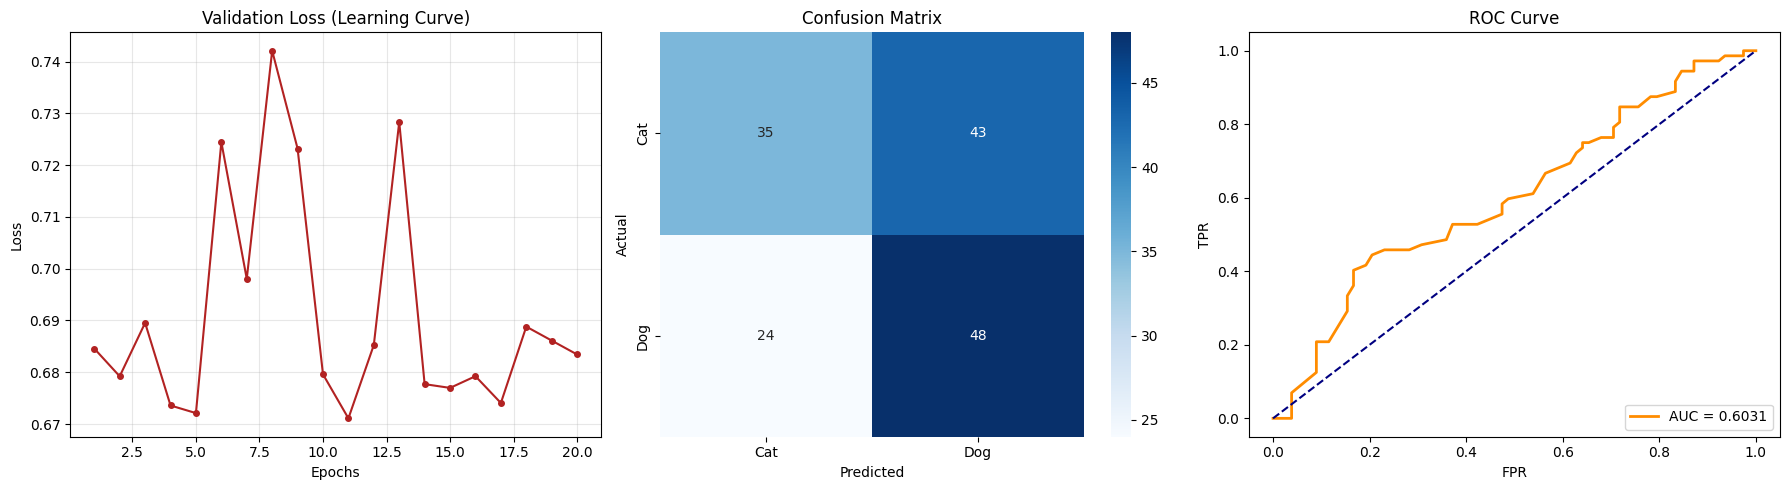

In [26]:
# --- FINAL EXECUTION BLOCK ---
# We use 20 epochs because your logs showed loss climbing after that (Overfitting)
net = BrainNet([X_train.shape[1], 128, 64, 1], lr=0.0001)
history = {"loss": [], "acc": []}

print("Final Training Session Starting...")

for epoch in range(20):
    p = np.random.permutation(len(X_train))
    x_s, y_s = X_train[p], y_train[p]

    for i in range(0, len(X_train), 16):
        xb, yb = x_s[i:i+16], y_s[i:i+16]
        net.step_forward(xb)
        net.step_backward(yb)

    # Progress check
    v_probs = net.step_forward(X_val).flatten()
    v_acc = np.mean((v_probs >= 0.5) == y_val)
    v_loss = bce_loss(y_val, v_probs)

    history["loss"].append(v_loss)
    history["acc"].append(v_acc)
    print(f"Epoch {epoch+1}/20 | Loss: {v_loss:.4f} | Acc: {v_acc:.4f}")

# --- Metrics Calculation ---
test_probs = net.step_forward(X_test).flatten()
# Ensure these variables are all captured from your custom functions
acc, prec, rec, f1, auc_val, matrix = get_performance(y_test, test_probs)
fpr, tpr = get_roc_coordinates(y_test, test_probs)

# --- Final Plots ---
# Explicitly create subplots to avoid the "0 Axes" error
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Learning Curve
ax[0].plot(range(1, len(history["loss"]) + 1), history["loss"], color='firebrick', marker='o', markersize=4)
ax[0].set_title("Validation Loss (Learning Curve)")
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Loss")
ax[0].grid(True, alpha=0.3)

# Plot 2: Confusion Matrix
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', ax=ax[1],
            xticklabels=['Cat', 'Dog'], yticklabels=['Cat', 'Dog'])
ax[1].set_title("Confusion Matrix")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("Actual")

# Plot 3: ROC Curve
ax[2].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc_val:.4f}')
ax[2].plot([0, 1], [0, 1], color='navy', linestyle='--')
ax[2].set_title("ROC Curve")
ax[2].set_xlabel("FPR")
ax[2].set_ylabel("TPR")
ax[2].legend(loc="lower right")

plt.tight_layout()
plt.show() # This will force the render in Colab